# 11-14.Modeling (Sentiment Analysis) Machine Learning

In [1]:
import pandas as pd
from pathlib import Path
import os

In [2]:
current_dir = Path.cwd()
data_path = os.path.join(current_dir, "sampled_reviews.csv")

print("current_dir:", current_dir)
print("data_path:", data_path)


current_dir: /Users/rebecca/Documents/CROUSE/Winter-2025/COMP262-NLP_RS/Project/W25_COMP262_002_TeamGamma
data_path: /Users/rebecca/Documents/CROUSE/Winter-2025/COMP262-NLP_RS/Project/W25_COMP262_002_TeamGamma/sampled_reviews.csv


In [3]:
#load data

data = pd.read_csv(data_path)

In [4]:
pd.set_option('display.max_colwidth', None)

In [5]:
data.head()

,overall,verified,reviewTime,reviewerID,asin,reviewerName,reviewText,summary,unixReviewTime,vote,style,image,reviewText_length_words,summary_length_words,label
0,5,True,"08 18, 2015",A15ZDMON8G1OI5,B00DCGWYKI,Art Rodriguez,Fast delivery and effective. Exactly what I wanted. Thank you!!,Five Stars,1439856000,NaN,NaN,NaN,10,2,POSITIVE
1,1,True,"08 19, 2016",A1RSNXJADULT5R,B01EJMLO8G,H C,"Operator manual confusing. Refers to wire feeding button and wire loading button, but no such buttons are shown on diagram. Pen heated up once and then quit working. Expensive b'day present that left angry child and frustrated parents. All the seller wanted was for me to write product review.",Poor product. Won't buy this again.,1471564800,15.0,NaN,NaN,49,6,NEGATIVE
2,1,True,"05 7, 2014",A1O8JACMOU1ZO1,B002PJEXEI,Matthew Hitzges,This stethoscope does not work properly. I recommend that you don't buy it. You will just be wasting your money.,Do Not Buy!,1399420800,NaN,NaN,NaN,20,3,NEGATIVE
3,5,True,"01 10, 2014",A1A1L113H9YOFS,B0058QKFBU,George H.,"I believe this is more than enough gaffer tape I will probably ever use.\n\nI just love the bright colors, just wish they had thrown in a roll of black also.",perfect rolls for travel!,1389312000,NaN,NaN,NaN,31,4,POSITIVE
4,5,True,"09 16, 2013",A3UKWDXIOOEZH7,B0050CFIQY,Samantha,"if you ever seen a 3 oz. bath and body works lotion, then you know that this product is smaller then 1 oz. its 0.18 oz. but it came right on time and i like it.",There not as big as the picture,1379289600,NaN,{'Size:': ' Single Pack'},NaN,36,7,POSITIVE


In [6]:
data.describe()

,overall,unixReviewTime,vote,reviewText_length_words,summary_length_words
count,2000.000000,2.000000e+03,178.000000,2000.000000,2000.000000
mean,4.392500,1.456038e+09,4.449438,19.803500,3.002000
std,1.174791,5.338697e+07,4.993807,20.150928,1.796833
min,1.000000,1.142381e+09,2.000000,1.000000,1.000000
25%,4.000000,1.426378e+09,2.000000,5.000000,2.000000
50%,5.000000,1.464264e+09,3.000000,12.000000,2.000000
75%,5.000000,1.494547e+09,5.000000,28.000000,4.000000
max,5.000000,1.536538e+09,53.000000,88.000000,9.000000


In [7]:
data.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   overall                  2000 non-null   int64  
 1   verified                 2000 non-null   bool   
 2   reviewTime               2000 non-null   object 
 3   reviewerID               2000 non-null   object 
 4   asin                     2000 non-null   object 
 5   reviewerName             2000 non-null   object 
 6   reviewText               2000 non-null   object 
 7   summary                  2000 non-null   object 
 8   unixReviewTime           2000 non-null   int64  
 9   vote                     178 non-null    float64
 10  style                    794 non-null    object 
 11  image                    23 non-null     object 
 12  reviewText_length_words  2000 non-null   int64  
 13  summary_length_words     2000 non-null   int64  
 14  label                   

## Distribution of Ratings

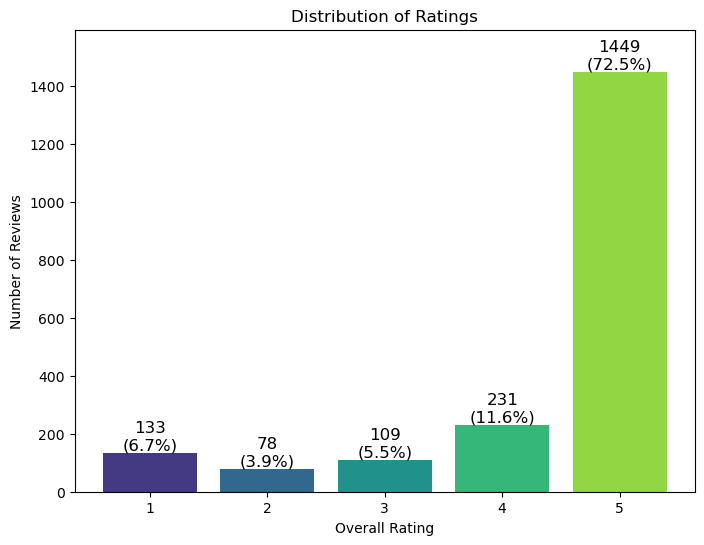

Ratings Distribution:
overall
1     133
2      78
3     109
4     231
5    1449
Name: count, dtype: int64


In [8]:
from matplotlib import pyplot as plt
import seaborn as sns

rating_counts = data['overall'].value_counts().sort_index()
total_reviews = rating_counts.sum()

colors = sns.color_palette("viridis", len(rating_counts))

plt.figure(figsize=(8,6))
bars = plt.bar(rating_counts.index, rating_counts.values, color=colors)
plt.xlabel("Overall Rating")
plt.ylabel("Number of Reviews")
plt.title("Distribution of Ratings")
plt.ylim(0, rating_counts.max() * 1.1)

for bar in bars:
    height = bar.get_height()
    percentage = (height / total_reviews) * 100
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f"{height}\n({percentage:.1f}%)",
             ha='center', va='bottom', fontsize=12)

plt.show()

print("Ratings Distribution:")
print(rating_counts)

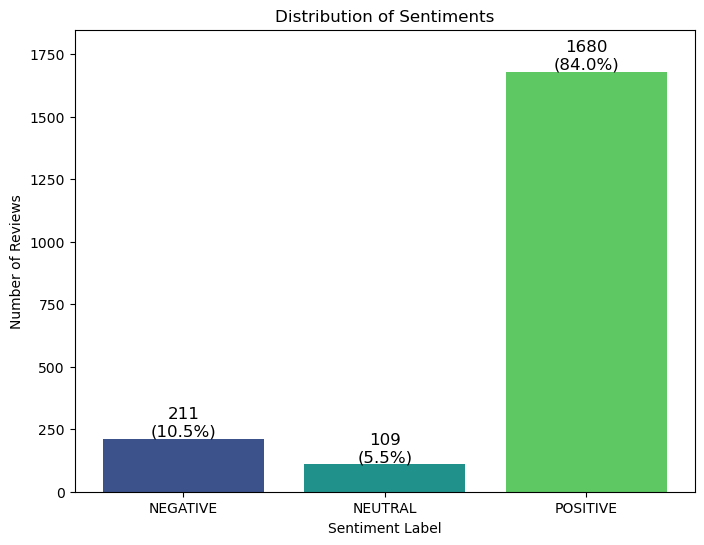

Sentiment Distribution:
label
NEGATIVE     211
NEUTRAL      109
POSITIVE    1680
Name: count, dtype: int64


In [9]:
desired_order = ["NEGATIVE", "NEUTRAL", "POSITIVE"]

rating_counts = data['label'].value_counts().reindex(desired_order)

total_reviews = rating_counts.sum()

colors = sns.color_palette("viridis", len(rating_counts))

plt.figure(figsize=(8,6))
bars = plt.bar(rating_counts.index, rating_counts.values, color=colors)

plt.xlabel("Sentiment Label")
plt.ylabel("Number of Reviews")
plt.title("Distribution of Sentiments")
plt.ylim(0, rating_counts.max() * 1.1)

for bar in bars:
    height = bar.get_height()
    percentage = (height / total_reviews) * 100
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f"{height}\n({percentage:.1f}%)",
             ha='center', va='bottom', fontsize=12)

plt.show()

print("Sentiment Distribution:")
print(rating_counts)

In [10]:
# check how many products in dataset

num_across_products = data['asin'].value_counts()

len(num_across_products)

1676

In [11]:
num_across_products.head(10)

asin
B00DRALJ28    17
B005KMDV9A    12
B00AZBIZTW    12
B00837ZGRY    11
B00DMI632G     9
B008YA6BWE     7
B0002EQU6C     7
B000F4OYMQ     7
B0013BKDO8     6
B00C351GBC     6
Name: count, dtype: int64

In [12]:
max(num_across_products.values)

17

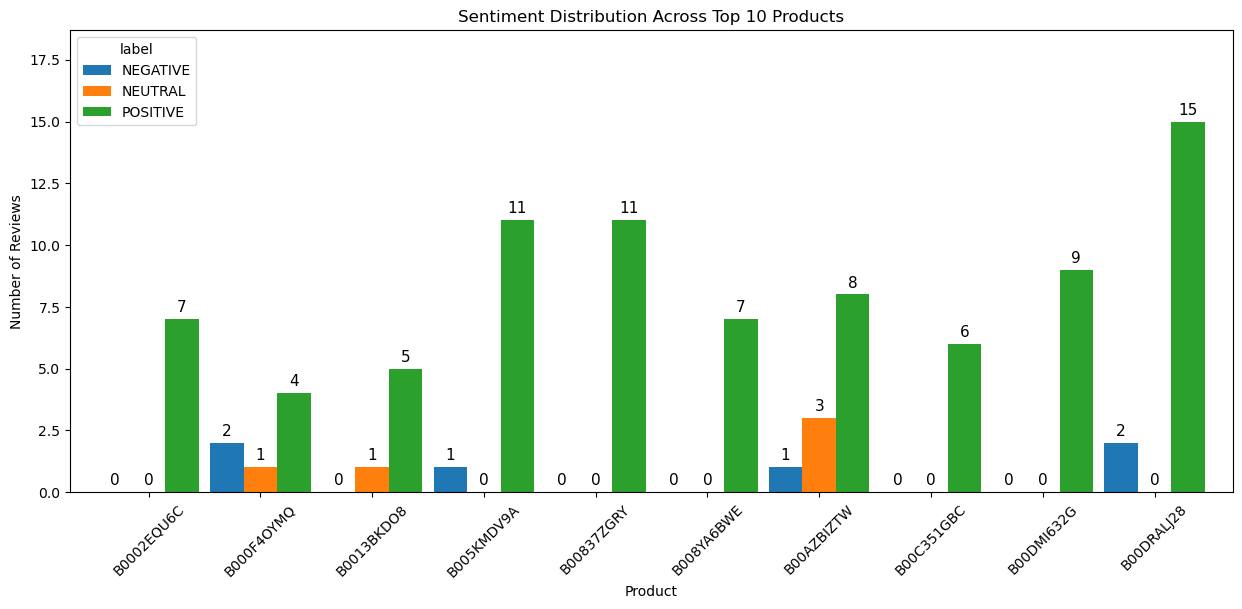

In [13]:
# Get the top 10 products based on the number of reviews (asin)
top_10_products = num_across_products.nlargest(10).index
data_top_10 = data[data['asin'].isin(top_10_products)]

# Count sentiments per product (asin) for the top 10 products
sentiment_counts = data_top_10.groupby(['asin', 'label']).size().unstack(fill_value=0)

# Plotting the sentiment distribution for the top 10 products
ax = sentiment_counts.plot(kind='bar', stacked=False, figsize=(15,6), width=0.9)
plt.title('Sentiment Distribution Across Top 10 Products')
plt.xlabel('Product')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45)
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize=11, padding=3)
plt.ylim(0, num_across_products.max() * 1.1)
plt.show()

In [14]:
data['reviewerID'].value_counts()

reviewerID
A15ZDMON8G1OI5    1
ABJRGLQSV4U6S     1
A3TFIJAUTCLCDO    1
A2BM10SKL5EJKO    1
A3NI800P6Q6YNS    1
                 ..
A2GZAAQT9116J8    1
A3OUAHZURGAVWL    1
A3554QZL7YM11L    1
A3E9B7P92TRSZL    1
A8G9UAVURCHQ      1
Name: count, Length: 2000, dtype: int64

In [15]:
# length
data['reviewText_length_words'] = data['reviewText'].apply(lambda x: len(str(x).split()))
correlation = data['reviewText_length_words'].corr(data['overall'])
print(f"\nCorrelation between review length and rating: {correlation:.2f}")


Correlation between review length and rating: -0.19


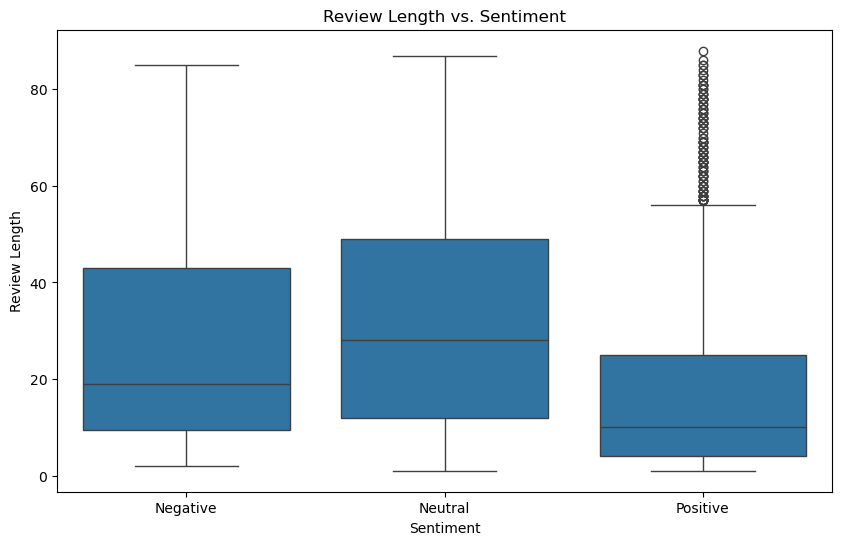

In [16]:
import numpy as np

data['sentiment'] = pd.cut(data['overall'],
                         bins=[-np.inf, 2, 3, np.inf],
                         labels=['Negative', 'Neutral', 'Positive'])

plt.figure(figsize=(10, 6))
sns.boxplot(x='sentiment', y='reviewText_length_words', data=data)
plt.title('Review Length vs. Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Review Length')
plt.show()

In [17]:
# preprocessing

data['full_text'] = data['summary']+" "+data['reviewText']

In [18]:
data.head()

,overall,verified,reviewTime,reviewerID,asin,reviewerName,reviewText,summary,unixReviewTime,vote,style,image,reviewText_length_words,summary_length_words,label,sentiment,full_text
0,5,True,"08 18, 2015",A15ZDMON8G1OI5,B00DCGWYKI,Art Rodriguez,Fast delivery and effective. Exactly what I wanted. Thank you!!,Five Stars,1439856000,NaN,NaN,NaN,10,2,POSITIVE,Positive,Five Stars Fast delivery and effective. Exactly what I wanted. Thank you!!
1,1,True,"08 19, 2016",A1RSNXJADULT5R,B01EJMLO8G,H C,"Operator manual confusing. Refers to wire feeding button and wire loading button, but no such buttons are shown on diagram. Pen heated up once and then quit working. Expensive b'day present that left angry child and frustrated parents. All the seller wanted was for me to write product review.",Poor product. Won't buy this again.,1471564800,15.0,NaN,NaN,49,6,NEGATIVE,Negative,"Poor product. Won't buy this again. Operator manual confusing. Refers to wire feeding button and wire loading button, but no such buttons are shown on diagram. Pen heated up once and then quit working. Expensive b'day present that left angry child and frustrated parents. All the seller wanted was for me to write product review."
2,1,True,"05 7, 2014",A1O8JACMOU1ZO1,B002PJEXEI,Matthew Hitzges,This stethoscope does not work properly. I recommend that you don't buy it. You will just be wasting your money.,Do Not Buy!,1399420800,NaN,NaN,NaN,20,3,NEGATIVE,Negative,Do Not Buy! This stethoscope does not work properly. I recommend that you don't buy it. You will just be wasting your money.
3,5,True,"01 10, 2014",A1A1L113H9YOFS,B0058QKFBU,George H.,"I believe this is more than enough gaffer tape I will probably ever use.\n\nI just love the bright colors, just wish they had thrown in a roll of black also.",perfect rolls for travel!,1389312000,NaN,NaN,NaN,31,4,POSITIVE,Positive,"perfect rolls for travel! I believe this is more than enough gaffer tape I will probably ever use.\n\nI just love the bright colors, just wish they had thrown in a roll of black also."
4,5,True,"09 16, 2013",A3UKWDXIOOEZH7,B0050CFIQY,Samantha,"if you ever seen a 3 oz. bath and body works lotion, then you know that this product is smaller then 1 oz. its 0.18 oz. but it came right on time and i like it.",There not as big as the picture,1379289600,NaN,{'Size:': ' Single Pack'},NaN,36,7,POSITIVE,Positive,"There not as big as the picture if you ever seen a 3 oz. bath and body works lotion, then you know that this product is smaller then 1 oz. its 0.18 oz. but it came right on time and i like it."


In [19]:
import re
def clean_text(text):
    text = re.sub(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b', '', text)
    text = re.sub(r'http[s]?://\S+|www\.\S+', '', text)
    text = re.sub(r'[@#$%&*]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [20]:
data['full_clean'] = data['full_text'].apply(clean_text)

In [21]:
df_data = data[['label', 'full_clean']]

In [22]:
df_data.head()

,label,full_clean
0,POSITIVE,Five Stars Fast delivery and effective. Exactly what I wanted. Thank you!!
1,NEGATIVE,"Poor product. Won't buy this again. Operator manual confusing. Refers to wire feeding button and wire loading button, but no such buttons are shown on diagram. Pen heated up once and then quit working. Expensive b'day present that left angry child and frustrated parents. All the seller wanted was for me to write product review."
2,NEGATIVE,Do Not Buy! This stethoscope does not work properly. I recommend that you don't buy it. You will just be wasting your money.
3,POSITIVE,"perfect rolls for travel! I believe this is more than enough gaffer tape I will probably ever use. I just love the bright colors, just wish they had thrown in a roll of black also."
4,POSITIVE,"There not as big as the picture if you ever seen a 3 oz. bath and body works lotion, then you know that this product is smaller then 1 oz. its 0.18 oz. but it came right on time and i like it."


## Split data

In [23]:
from sklearn.model_selection import train_test_split

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df_data['full_clean'], df_data['label'], test_size=0.3, stratify=df_data['label'], random_state=55
)

In [24]:
# "NEGATIVE": 0, "NEUTRAL": 1, "POSITIVE": 2

In [25]:
label_mapping = {"NEGATIVE": 0, "NEUTRAL": 1, "POSITIVE": 2}
y_train_num = y_train.map(label_mapping)
y_test_num = y_test.map(label_mapping)

# Lexicons

### VADR

In [26]:
X_test_vader = X_test_raw.copy()
df_vader = pd.DataFrame({'text': X_test_vader, 'label': y_test})

In [27]:
df_vader.head()

,text,label
1160,Five Stars Great product best shipping.,POSITIVE
1973,"Five Stars I love this vacuum so far! It has lots of suction, easy to dump dust bin, A++++++++",POSITIVE
1865,"Good rope good deal I am a rope user in a construction business and I am pleased with the price for the amount of rope you sell. Much better than buying off the shelf at lowes or some other local supplier. I Particularly like the 1/2 braided rope for daily use. I use it for binding loads, securing various things, lifting, pulling. It is very durable. Thank you. I have been in construction for 50 years.",POSITIVE
140,Five Stars Excellent tool as described. With a little practice.......,POSITIVE
732,Good to have but not really a very precise Good to have but not really a very precise tool because it is stamped instead of machined to tolerences.,NEUTRAL


In [28]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [29]:
analyzer = SentimentIntensityAnalyzer()

In [30]:
vadr_score = []
compound_score = []
predict_label =[]

In [31]:
# positive sentiment: compound score >= 0.05
# neutral sentiment: (compound score > -0.05) and (compound score < 0.05)
# negative sentiment: compound score <= -0.05

In [32]:
for sentence in df_vader['text']:
    vs = analyzer.polarity_scores(sentence)

    vadr_score.append(vs)

    compound_s = vs['compound']
    compound_score.append(compound_s)

    if compound_s >= 0.05:
        predict_label.append('POSITIVE')
    elif compound_s <= -0.05:
        predict_label.append('NEGATIVE')
    else:
        predict_label.append('NEUTRAL')

In [33]:
df_vader['vadr_score'] = vadr_score
df_vader['compound_score'] = compound_score
df_vader['predict_label'] = predict_label

In [34]:
df_vader.head()

,text,label,vadr_score,compound_score,predict_label
1160,Five Stars Great product best shipping.,POSITIVE,"{'neg': 0.0, 'neu': 0.325, 'pos': 0.675, 'compound': 0.8519}",0.8519,POSITIVE
1973,"Five Stars I love this vacuum so far! It has lots of suction, easy to dump dust bin, A++++++++",POSITIVE,"{'neg': 0.1, 'neu': 0.616, 'pos': 0.284, 'compound': 0.6996}",0.6996,POSITIVE
1865,"Good rope good deal I am a rope user in a construction business and I am pleased with the price for the amount of rope you sell. Much better than buying off the shelf at lowes or some other local supplier. I Particularly like the 1/2 braided rope for daily use. I use it for binding loads, securing various things, lifting, pulling. It is very durable. Thank you. I have been in construction for 50 years.",POSITIVE,"{'neg': 0.0, 'neu': 0.78, 'pos': 0.22, 'compound': 0.955}",0.9550,POSITIVE
140,Five Stars Excellent tool as described. With a little practice.......,POSITIVE,"{'neg': 0.0, 'neu': 0.709, 'pos': 0.291, 'compound': 0.5719}",0.5719,POSITIVE
732,Good to have but not really a very precise Good to have but not really a very precise tool because it is stamped instead of machined to tolerences.,NEUTRAL,"{'neg': 0.0, 'neu': 0.807, 'pos': 0.193, 'compound': 0.7366}",0.7366,POSITIVE


In [35]:
from sklearn.metrics import classification_report
report_vadr = classification_report(df_vader['label'], df_vader['predict_label'],output_dict=True)
print(report_vadr)

{'NEGATIVE': {'precision': 0.6470588235294118, 'recall': 0.5238095238095238, 'f1-score': 0.5789473684210527, 'support': 63.0}, 'NEUTRAL': {'precision': 0.0641025641025641, 'recall': 0.15151515151515152, 'f1-score': 0.09009009009009009, 'support': 33.0}, 'POSITIVE': {'precision': 0.921443736730361, 'recall': 0.8611111111111112, 'f1-score': 0.8902564102564102, 'support': 504.0}, 'accuracy': 0.7866666666666666, 'macro avg': {'precision': 0.544201708120779, 'recall': 0.5121452621452621, 'f1-score': 0.5197646229225176, 'support': 600.0}, 'weighted avg': {'precision': 0.8454795563497325, 'recall': 0.7866666666666666, 'f1-score': 0.81355981325455, 'support': 600.0}}


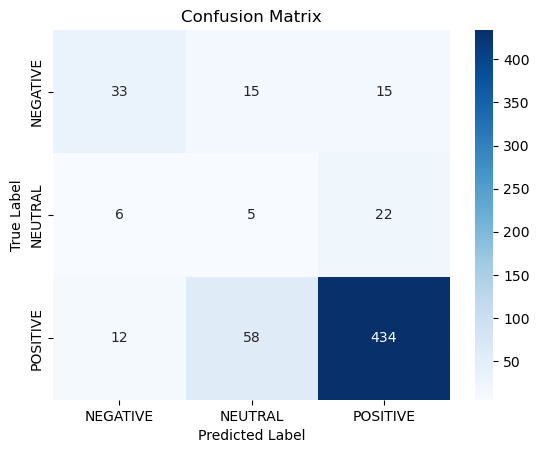

In [36]:
from sklearn.metrics import confusion_matrix

cm_vader = confusion_matrix(df_vader['label'], df_vader['predict_label'], labels=['NEGATIVE', 'NEUTRAL', 'POSITIVE'])
sns.heatmap(cm_vader, annot=True, fmt="d", cmap="Blues", xticklabels=['NEGATIVE', 'NEUTRAL', 'POSITIVE'], yticklabels=['NEGATIVE', 'NEUTRAL', 'POSITIVE'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

### Textblob

In [37]:
from textblob import TextBlob

In [38]:
from nltk.corpus import stopwords
import nltk
from nltk.tokenize import word_tokenize
from textblob import Word

# nltk.download('stopwords')
# nltk.download('punkt')

def preprocessing_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    #Tokenization
    text = word_tokenize(text)
    #Lemmatization
    text = [Word(word).lemmatize() for word in text]

    # Remove stop words
    stop_words = set(stopwords.words('english'))
    text = [word for word in text if word not in stop_words]
    
    return " ".join(text)

In [39]:
def clean_text_textblob(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    return text

In [40]:
X_test_blob = X_test_raw.apply(preprocessing_text)
X_test_blob = X_test_blob.apply(clean_text_textblob)

In [41]:
df_textblob = pd.DataFrame({'cleaned_text': X_test_blob, 'label': y_test})

In [42]:
df_textblob.head()

,cleaned_text,label
1160,five star great product best shipping,POSITIVE
1973,five star love vacuum far ha lot suction easy dump dust bin,POSITIVE
1865,good rope good deal rope user construction business pleased price amount rope sell much better buying shelf lowes local supplier particularly like 12 braided rope daily use use binding load securing various thing lifting pulling durable thank construction 50 year,POSITIVE
140,five star excellent tool described little practice,POSITIVE
732,good really precise good really precise tool stamped instead machined tolerences,NEUTRAL


In [43]:
df_textblob['polarity'] = df_textblob['cleaned_text'].astype(str).map(lambda text: TextBlob(text).sentiment.polarity)

df_textblob['review_len'] = df_textblob['cleaned_text'].astype(str).apply(len)
df_textblob['word_count'] = df_textblob['cleaned_text'].apply(lambda x: len(str(x).split()))

In [44]:
df_textblob['blob_sentiment_label'] = df_textblob['polarity'].apply(lambda x: 'POSITIVE' if x > 0.05 else ('NEGATIVE' if x < -0.05 else 'NEUTRAL'))

df_textblob[['label', 'cleaned_text', 'polarity', 'blob_sentiment_label']]

,label,cleaned_text,polarity,blob_sentiment_label
1160,POSITIVE,five star great product best shipping,0.900000,POSITIVE
1973,POSITIVE,five star love vacuum far ha lot suction easy dump dust bin,0.256250,POSITIVE
1865,POSITIVE,good rope good deal rope user construction business pleased price amount rope sell much better buying shelf lowes local supplier particularly like 12 braided rope daily use use binding load securing various thing lifting pulling durable thank construction 50 year,0.320833,POSITIVE
140,POSITIVE,five star excellent tool described little practice,0.406250,POSITIVE
732,NEUTRAL,good really precise good really precise tool stamped instead machined tolerences,0.550000,POSITIVE
...,...,...,...,...
743,POSITIVE,great tape speedy service great tape,0.800000,POSITIVE
1961,POSITIVE,five star work great easy get around,0.616667,POSITIVE
22,POSITIVE,five star perfect fit great price,0.733333,POSITIVE
634,NEGATIVE,doe function doesnt work dont buy dont buy dont buy,0.000000,NEUTRAL


In [45]:
from sklearn.metrics import classification_report
report_textblob = classification_report(df_textblob['label'], df_textblob['blob_sentiment_label'],output_dict=True)
print(report_textblob)

{'NEGATIVE': {'precision': 0.55, 'recall': 0.3492063492063492, 'f1-score': 0.42718446601941745, 'support': 63.0}, 'NEUTRAL': {'precision': 0.11956521739130435, 'recall': 0.3333333333333333, 'f1-score': 0.176, 'support': 33.0}, 'POSITIVE': {'precision': 0.9038461538461539, 'recall': 0.8392857142857143, 'f1-score': 0.8703703703703703, 'support': 504.0}, 'accuracy': 0.76, 'macro avg': {'precision': 0.5244704570791527, 'recall': 0.5072751322751322, 'f1-score': 0.4911849454632626, 'support': 600.0}, 'weighted avg': {'precision': 0.823556856187291, 'recall': 0.76, 'f1-score': 0.7856454800431498, 'support': 600.0}}


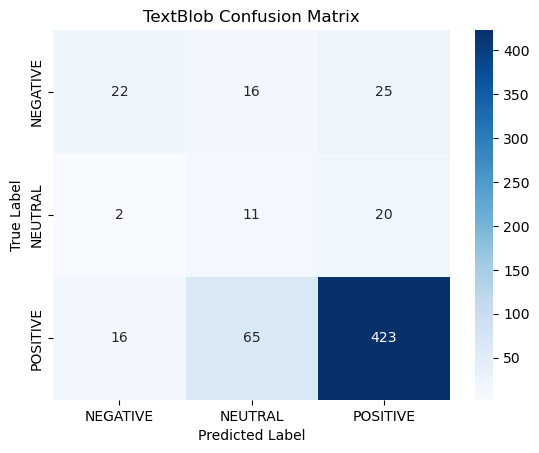

In [46]:
cm_textblob = confusion_matrix(df_textblob['label'], df_textblob['blob_sentiment_label'], labels=['NEGATIVE', 'NEUTRAL', 'POSITIVE'])
sns.heatmap(cm_textblob, annot=True, fmt="d", cmap="Blues", xticklabels=['NEGATIVE', 'NEUTRAL', 'POSITIVE'], yticklabels=['NEGATIVE', 'NEUTRAL', 'POSITIVE'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("TextBlob Confusion Matrix")
plt.show()

# Machine Learning

In [47]:
# TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

X_train_preprocessing = X_train_raw.apply(preprocessing_text)
X_train_clean = X_train_preprocessing.apply(clean_text_textblob)

tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train_clean)
X_test_tfidf = tfidf.transform(X_test_blob)

In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

### SVM

In [49]:
pipeline_svm = Pipeline([
    ('svc', SVC(probability=True))
])

param_grid = {
    'svc__kernel': ['linear', 'rbf', 'poly'],
    'svc__C': [0.1, 1, 10], 
    'svc__gamma': ['scale', 'auto']
}

# GridSearchCV
grid_search_svm = GridSearchCV(pipeline_svm, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_svm.fit(X_train_tfidf, y_train_num)

# Best model
best_model_svm = grid_search_svm.best_estimator_

In [50]:
print("Best Parameters:", best_model_svm)
print("Best Accuracy on Validation:", grid_search_svm.best_score_)

Best Parameters: Pipeline(steps=[('svc', SVC(C=1, kernel='linear', probability=True))])
Best Accuracy on Validation: 0.8821428571428571


In [51]:
# Predict
best_model_svm.fit(X_train_tfidf, y_train_num)

y_pred_svm = best_model_svm.predict(X_test_tfidf)

report_svm = classification_report(y_test_num, y_pred_svm, output_dict=True)
cm_svm = confusion_matrix(y_test_num, y_pred_svm)
acc_svm = accuracy_score(y_test_num, y_pred_svm)
precision_svm = precision_score(y_test_num, y_pred_svm, average='weighted', zero_division=0)
recall_svm = recall_score(y_test_num, y_pred_svm, average='weighted', zero_division=0)

In [52]:
# {0: "NEGATIVE", 1: "NEUTRAL", 2: "POSITIVE"}
inv_label_mapping = {v: k for k, v in label_mapping.items()}

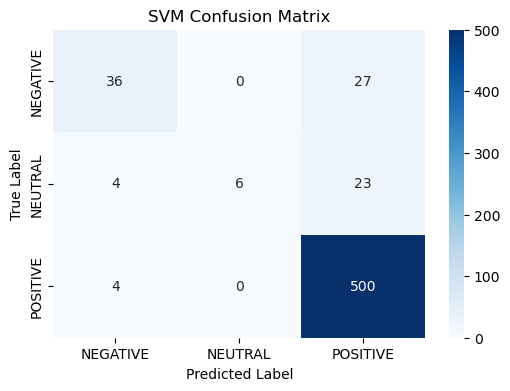

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

labels = sorted(inv_label_mapping.keys())
string_labels = [inv_label_mapping[i] for i in labels]

plt.figure(figsize=(6, 4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=string_labels,
            yticklabels=string_labels)
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

### MLP

In [54]:
pipeline_mlp = Pipeline([
    ('mlp', MLPClassifier(max_iter=300, random_state=42))
])

param_grid_mlp = {
    'mlp__hidden_layer_sizes': [(100,), (50, 50), (100, 50)],
    'mlp__activation': ['relu', 'tanh'],
    'mlp__alpha': [0.0001, 0.001], 
    'mlp__solver': ['adam', 'lbfgs']
}

grid_search_mlp = GridSearchCV(
    pipeline_mlp,
    param_grid=param_grid_mlp,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_mlp.fit(X_train_tfidf, y_train_num)

best_model_mlp = grid_search_mlp.best_estimator_

In [55]:
print("Best Parameters:", best_model_mlp)
print("Best Accuracy on Validation:", grid_search_mlp.best_score_)

Best Parameters: Pipeline(steps=[('mlp', MLPClassifier(max_iter=300, random_state=42))])
Best Accuracy on Validation: 0.8800000000000001


In [56]:
model_mlp = MLPClassifier(hidden_layer_sizes=(100,), max_iter=300)
model_mlp.fit(X_train_tfidf, y_train_num)

y_pred_mlp = best_model_mlp.predict(X_test_tfidf)

report_mlp = classification_report(y_test_num, y_pred_mlp, output_dict=True)

cm_mlp = confusion_matrix(y_test_num, y_pred_mlp)
acc_mlp = accuracy_score(y_test_num, y_pred_mlp)
precision_mlp = precision_score(y_test_num, y_pred_mlp, average='weighted', zero_division=0)
recall_mlp = recall_score(y_test_num, y_pred_mlp, average='weighted', zero_division=0)        

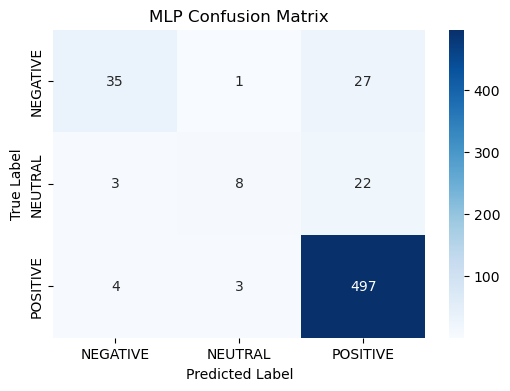

In [57]:
plt.figure(figsize=(6, 4))
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Blues',
            xticklabels=string_labels,
            yticklabels=string_labels)
plt.title("MLP Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## GradientBoostingClassifier

In [58]:
pipeline_gb = Pipeline([
    ('gb', GradientBoostingClassifier(random_state=42))
])

param_grid_gb = {
    'gb__n_estimators': [100, 150],
    'gb__learning_rate': [0.1, 0.05],
    'gb__max_depth': [3, 5],
    'gb__subsample': [1.0, 0.8]
}

grid_search_gb = GridSearchCV(
    pipeline_gb,
    param_grid=param_grid_gb,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_gb.fit(X_train_tfidf, y_train_num)

best_model_gb = grid_search_gb.best_estimator_

y_pred_gb = best_model_gb.predict(X_test_tfidf)

report_gb = classification_report(y_test_num, y_pred_gb, output_dict=True)
cm_gb = confusion_matrix(y_test_num, y_pred_gb)
acc_gb = accuracy_score(y_test_num, y_pred_gb)
precision_gb = precision_score(y_test_num, y_pred_gb, average='weighted', zero_division=0)
recall_gb = recall_score(y_test_num, y_pred_gb, average='weighted', zero_division=0)

print("Best Parameters:", best_model_gb)
print("Best Accuracy on Validation:", grid_search_gb.best_score_)

Best Parameters: Pipeline(steps=[('gb',
                 GradientBoostingClassifier(random_state=42, subsample=0.8))])
Best Accuracy on Validation: 0.8835714285714286


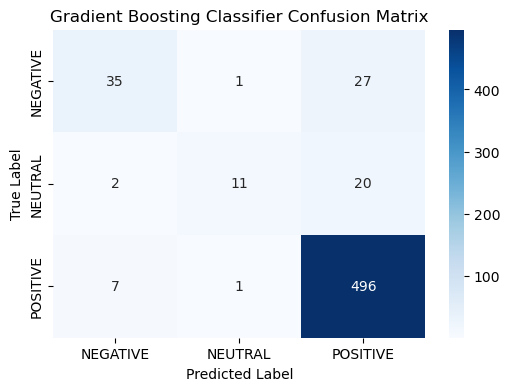

In [59]:
plt.figure(figsize=(6, 4))
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Blues',
            xticklabels=string_labels,
            yticklabels=string_labels)
plt.title("Gradient Boosting Classifier Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## Logistic Regression

In [60]:
pipeline_lr = Pipeline([
    ('lr', LogisticRegression(max_iter=500, random_state=42))
])

param_grid_lr = {
    'lr__C': [0.1, 1, 10],
    'lr__penalty': ['l2'],
    'lr__solver': ['newton-cg', 'saga','lbfgs']
}

grid_search_lr = GridSearchCV(pipeline_lr, param_grid_lr, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_lr.fit(X_train_tfidf, y_train_num)

best_lr_model = grid_search_lr.best_estimator_

print("Logistic Regression Best Params:", grid_search_lr.best_params_)
print("Best Accuracy on Validation:", grid_search_lr.best_score_)

Logistic Regression Best Params: {'lr__C': 10, 'lr__penalty': 'l2', 'lr__solver': 'lbfgs'}
Best Accuracy on Validation: 0.8785714285714284


In [61]:
y_pred_lr = best_lr_model.predict(X_test_tfidf)

report_lr = classification_report(y_test_num, y_pred_lr, output_dict=True)
cm_lr = confusion_matrix(y_test_num, y_pred_lr)
acc_lr = accuracy_score(y_test_num, y_pred_lr)
precision_lr = precision_score(y_test_num, y_pred_lr, average='weighted', zero_division=0)
recall_lr = recall_score(y_test_num, y_pred_lr, average='weighted', zero_division=0)

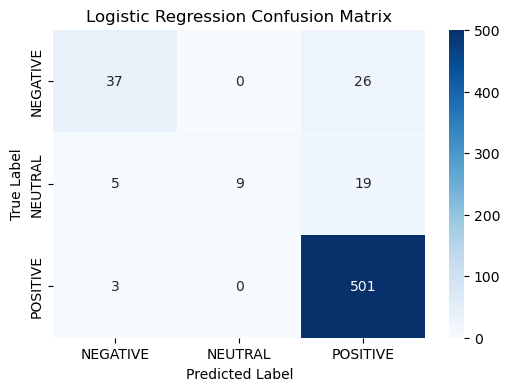

In [62]:
plt.figure(figsize=(6, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=string_labels,
            yticklabels=string_labels)
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## Naïve Bayes

In [63]:
pipeline_nb = Pipeline([
    ('nb', MultinomialNB())
])

param_grid_nb = {
    'nb__alpha': [0.1, 0.5, 1.0]
}

grid_search_nb = GridSearchCV(pipeline_nb, param_grid_nb, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_nb.fit(X_train_tfidf, y_train_num)

best_model_nb = grid_search_nb.best_estimator_

print("MultinomialNB Best Params:", grid_search_nb.best_params_)
print("Accuracy:", grid_search_nb.best_score_)

y_pred_nb = best_model_nb.predict(X_test_tfidf)

report_nb = classification_report(y_test_num, y_pred_nb, output_dict=True)
cm_nb = confusion_matrix(y_test_num, y_pred_nb)
acc_nb = accuracy_score(y_test_num, y_pred_nb)
precision_nb = precision_score(y_test_num, y_pred_nb, average='weighted', zero_division=0)
recall_nb = recall_score(y_test_num, y_pred_nb, average='weighted', zero_division=0)

MultinomialNB Best Params: {'nb__alpha': 0.1}
Accuracy: 0.8507142857142858


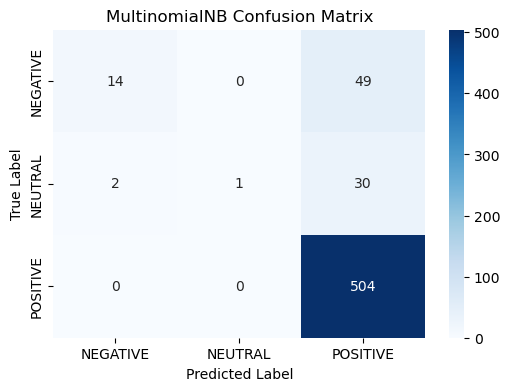

In [64]:
plt.figure(figsize=(6, 4))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues',
            xticklabels=string_labels,
            yticklabels=string_labels)
plt.title("MultinomialNB Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Compare

In [65]:
svm_scores = {
    "Model": "SVM",
    "Accuracy": acc_svm,
    "Precision": precision_svm,
    "Recall": recall_svm,
    "F1 Score": report_svm["weighted avg"]["f1-score"]
}

mlp_scores = {
    "Model": "MLP",
    "Accuracy": acc_mlp,
    "Precision": precision_mlp,
    "Recall": recall_mlp,
    "F1 Score": report_mlp["weighted avg"]["f1-score"]
}

gb_scores = {
    "Model": "GB",
    "Accuracy": acc_gb,
    "Precision": precision_gb,
    "Recall": recall_gb,
    "F1 Score": report_gb["weighted avg"]["f1-score"]
}

lr_scores = {
    "Model": "LR",
    "Accuracy": acc_lr,
    "Precision": precision_lr,
    "Recall": recall_lr,
    "F1 Score": report_lr["weighted avg"]["f1-score"]
}

nb_scores = {
    "Model": "NB",
    "Accuracy": acc_nb,
    "Precision": precision_nb,
    "Recall": recall_nb,
    "F1 Score": report_nb["weighted avg"]["f1-score"]
}

# DataFrame
df_scores_5 = pd.DataFrame([svm_scores, mlp_scores,gb_scores,lr_scores,nb_scores])

df_scores_5

,Model,Accuracy,Precision,Recall,F1 Score
0,SVM,0.903333,0.904545,0.903333,0.884541
1,MLP,0.900000,0.888782,0.900000,0.884756
2,GB,0.903333,0.897354,0.903333,0.890870
3,LR,0.911667,0.912103,0.911667,0.897116
4,NB,0.865000,0.873050,0.865000,0.819402


In [66]:
label_name_mapping = label_map = {'0': 'NEGATIVE', '1': 'NEUTRAL', '2': 'POSITIVE'}

report_svm_named = {
    label_name_mapping.get(k, k): v for k, v in report_svm.items()
}

report_mlp_named = {
    label_name_mapping.get(k, k): v for k, v in report_mlp.items()
}

report_nb_named = {
    label_name_mapping.get(k, k): v for k, v in report_nb.items()
}

report_lr_named = {
    label_name_mapping.get(k, k): v for k, v in report_lr.items()
}

report_gb_named = {
    label_name_mapping.get(k, k): v for k, v in report_gb.items()
}


In [67]:
all_reports = {
    'SVM': report_svm_named,
    'MLP': report_mlp_named,
    'NB': report_nb_named,
    'LR': report_lr_named,
    'GB': report_gb_named
}

In [68]:
neg_label = 'NEGATIVE'
neu_label = 'NEUTRAL'
pos_label = 'POSITIVE'

In [69]:
print(neg_label)
for model, report in all_reports.items():
    print(model)
    print(report[neg_label])

NEGATIVE
SVM
{'precision': 0.8181818181818182, 'recall': 0.5714285714285714, 'f1-score': 0.6728971962616822, 'support': 63.0}
MLP
{'precision': 0.8333333333333334, 'recall': 0.5555555555555556, 'f1-score': 0.6666666666666666, 'support': 63.0}
NB
{'precision': 0.875, 'recall': 0.2222222222222222, 'f1-score': 0.35443037974683544, 'support': 63.0}
LR
{'precision': 0.8222222222222222, 'recall': 0.5873015873015873, 'f1-score': 0.6851851851851852, 'support': 63.0}
GB
{'precision': 0.7954545454545454, 'recall': 0.5555555555555556, 'f1-score': 0.6542056074766355, 'support': 63.0}


In [70]:
print(neu_label)
for model, report in all_reports.items():
    print(model)
    print(report[neu_label])

NEUTRAL
SVM
{'precision': 1.0, 'recall': 0.18181818181818182, 'f1-score': 0.3076923076923077, 'support': 33.0}
MLP
{'precision': 0.6666666666666666, 'recall': 0.24242424242424243, 'f1-score': 0.35555555555555557, 'support': 33.0}
NB
{'precision': 1.0, 'recall': 0.030303030303030304, 'f1-score': 0.058823529411764705, 'support': 33.0}
LR
{'precision': 1.0, 'recall': 0.2727272727272727, 'f1-score': 0.42857142857142855, 'support': 33.0}
GB
{'precision': 0.8461538461538461, 'recall': 0.3333333333333333, 'f1-score': 0.4782608695652174, 'support': 33.0}


In [71]:
print(pos_label)
for model, report in all_reports.items():
    print(model)
    print(report[pos_label])

POSITIVE
SVM
{'precision': 0.9090909090909091, 'recall': 0.9920634920634921, 'f1-score': 0.9487666034155597, 'support': 504.0}
MLP
{'precision': 0.9102564102564102, 'recall': 0.9861111111111112, 'f1-score': 0.9466666666666667, 'support': 504.0}
NB
{'precision': 0.8644939965694682, 'recall': 1.0, 'f1-score': 0.9273229070837167, 'support': 504.0}
LR
{'precision': 0.9175824175824175, 'recall': 0.9940476190476191, 'f1-score': 0.9542857142857143, 'support': 504.0}
GB
{'precision': 0.9134438305709024, 'recall': 0.9841269841269841, 'f1-score': 0.9474689589302769, 'support': 504.0}
